# Part 1: Time Series Analysis (1 day)📈

What is a time serie ? Simply put, it's a dataset where each value is measured at a known given time. Whether it's stock prices, temperature measurements, sales figures, or any other sequential data, time series data holds a rich tapestry of information about how phenomena evolve over time. Typically with time series, we want to estimate the evolution of a phenomenom with time i.e. make predictions for the future. Thus, the temporal order of the dataset is of paramount significance!

Unlike cross-sectional data, where observations are independent of each other, the temporal arrangement in time series carries inherent dependencies. Patterns, trends, and seasonal variations often emerge, providing invaluable insights into the behavior of the underlying process.

In this notebook, we will manipulate a simple time series dataset with Pandas to explore the following concepts:
- Patterns (Trend, Seasonality, Noise) and Additive / Multiplicative decomposition
- Stationarity & Heteroskedasticity (Differencing & Log transform)
- Autocorrelation (ACF, PACF)

**Objectives**
- Get to know the theory behind time series
- Analyse time series datasets with Pandas
- Discover main time series analysis challenges

**Resources**

- https://www.youtube.com/watch?v=FsroWpkUuYI&list=PLjwX9KFWtvNnOc4HtsvaDf1XYG3O5bv5s
- https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html
- https://www.kaggle.com/code/prashant111/complete-guide-on-time-series-analysis-in-python
- https://perso.math.univ-toulouse.fr/jydauxoi/files/2017/04/poly_eleves.pdf

**Required librairies**
- [ ] numpy
- [ ] pandas
- [ ] matplotlib
- [ ] seaborn
- [ ] pmdarima

In [2]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm

# 1. Manipulate time series with Pandas

### 1.1 Load & visualize the Air Passengers dataset ✈️ 💺

Learn how to manipulate a Pandas series.

**Resources**
- https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html

**TODO**
- Load and visualize the dataset
- What can you tell about the overall trend of the data ?
- Select and plot a specific year (e.g. 1952) from the data using the `.index.year` attribute

In [9]:
from pmdarima.datasets import load_airpassengers

# Load dataset
START_DATE = '1949-01-01'
airline = load_airpassengers(as_series=True)

# There's no DateTimeIndex from the bundled dataset. So let's add one.
airline.index = pd.date_range(START_DATE, periods=len(airline), freq='MS')

# Write definitions to visualize, describe and eventually clean data
print("Shape :", airline.shape)
print("Période :", airline.index.min(), "→", airline.index.max())
print("Fréquence :", airline.index.freq)
print("\nStatistiques descriptives :")
print(airline.describe())

Shape : (144,)
Période : 1949-01-01 00:00:00 → 1960-12-01 00:00:00
Fréquence : <MonthBegin>

Statistiques descriptives :
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
dtype: float64


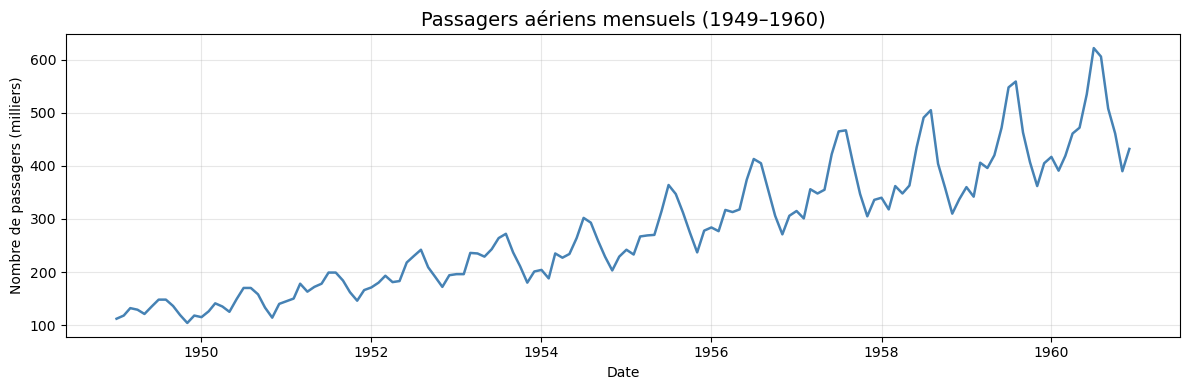

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(airline.index, airline.values, color='steelblue', linewidth=1.8)
ax.set_title("Passagers aériens mensuels (1949–1960)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de passagers (milliers)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

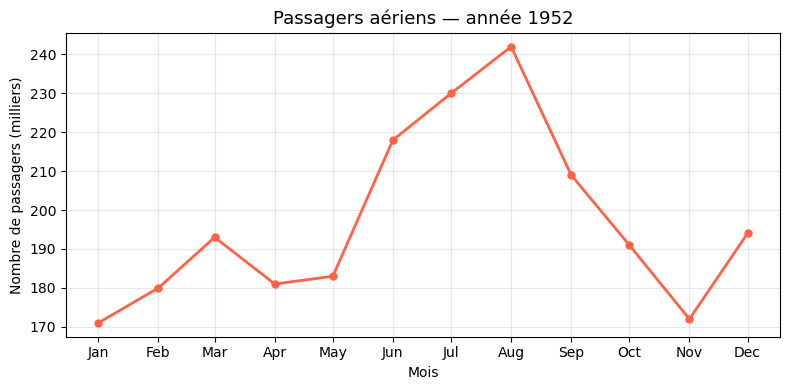

In [11]:
# Sélection et visualisation d'une année spécifique 
year = 1952
airline_1952 = airline[airline.index.year == year]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(airline_1952.index, airline_1952.values,
        color='tomato', linewidth=2, marker='o', markersize=5)
ax.set_title(f"Passagers aériens — année {year}", fontsize=13)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de passagers (milliers)")
ax.set_xticks(airline_1952.index)
ax.set_xticklabels([d.strftime('%b') for d in airline_1952.index])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Change the sampling (D/M/Y)

Different months have different numbers of days. Calculating the number of passengers per day might help remove this uninteresting variation from the series!

**TODO**
- Create a new time serie representing the daily number of passengers using the `.index.days_in_month` attribute
- Visualize the old and new serie: do you observe any difference ?

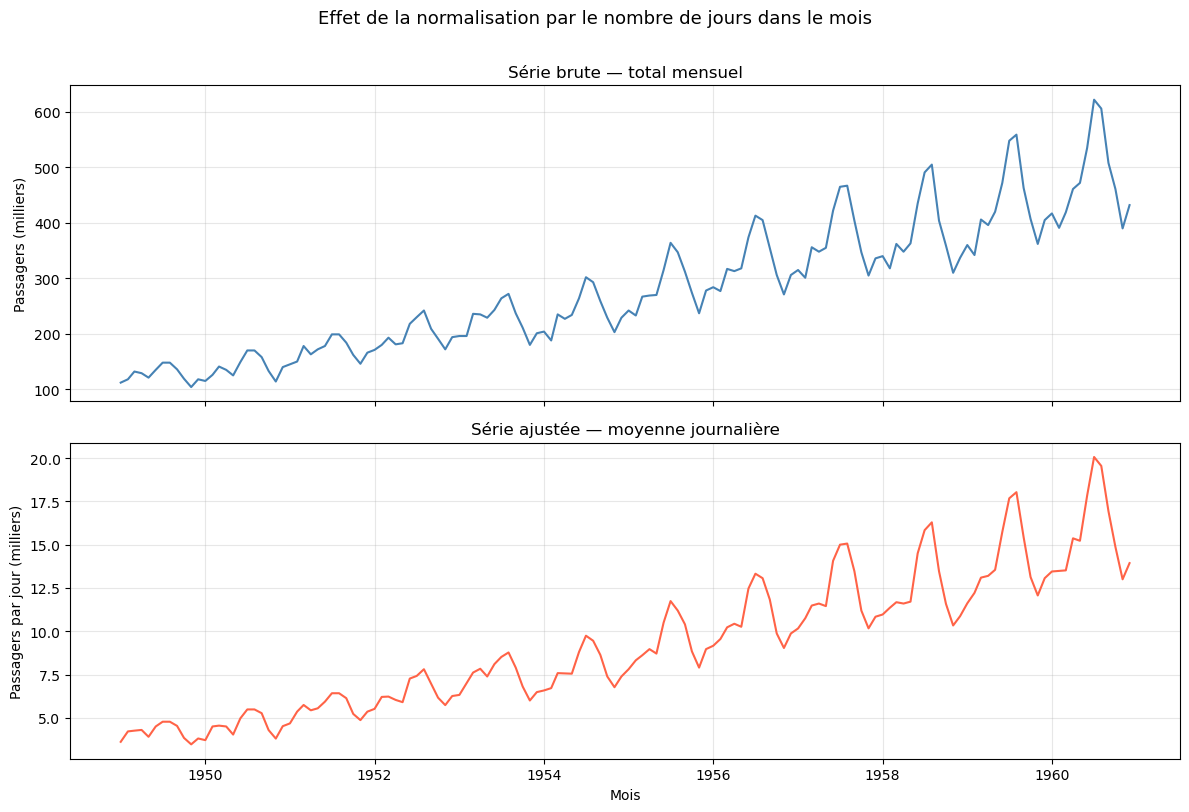

In [12]:
# Calculate the number of airline passengers per day instead of months

airline_adj = airline / airline.index.days_in_month
# Plot the unadjusted and adjusted series
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

axes[0].plot(airline, color='steelblue', linewidth=1.5)
axes[0].set(title='Série brute — total mensuel', ylabel='Passagers (milliers)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(airline_adj, color='tomato', linewidth=1.5)
axes[1].set(title='Série ajustée — moyenne journalière',
            xlabel='Mois', ylabel='Passagers par jour (milliers)')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Effet de la normalisation par le nombre de jours dans le mois",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
#Vérification numérique sur quelques mois
print("Comparaison brut vs ajusté (6 premiers mois) :\n")
comparison = pd.DataFrame({
    'Passagers bruts': airline.iloc[:6].values,
    'Jours dans le mois': airline.index.days_in_month[:6],
    'Passagers/jour': airline_adj.iloc[:6].round(2).values
}, index=airline.index[:6].strftime('%Y-%m'))
print(comparison)

Comparaison brut vs ajusté (6 premiers mois) :

         Passagers bruts  Jours dans le mois  Passagers/jour
1949-01            112.0                  31            3.61
1949-02            118.0                  28            4.21
1949-03            132.0                  31            4.26
1949-04            129.0                  30            4.30
1949-05            121.0                  31            3.90
1949-06            135.0                  30            4.50


### 1.3 Interpolation

Interpolation is useful when there are missing values which we don't want to discard completely. As such, it can be used instead of the now well-known `dropna()` method.

Another use case for interpolation is when resampling a time series. The airline passengers data is given with 1 month intervals. What if we want to know (and predict) the airline frequentation at smaller intervals ? For this we can use the `resample()` and `interpolate` methods!

**Resources**
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.html <br/>

**TODO**
- Select a single year from the dataset and resample it to daily time
- Call `resample()` to resample the series to daily intervals
- Call `interpolate()` and play with the different methods
- Plot the results to show the differences  

Série mensuelle 1955 : 12 points
1955-01-01    242.0
1955-02-01    233.0
1955-03-01    267.0
1955-04-01    269.0
1955-05-01    270.0
1955-06-01    315.0
1955-07-01    364.0
1955-08-01    347.0
1955-09-01    312.0
1955-10-01    274.0
1955-11-01    237.0
1955-12-01    278.0
Freq: MS, dtype: float64

Après resample journalier : 335 points
NaN créés : 323 / 335


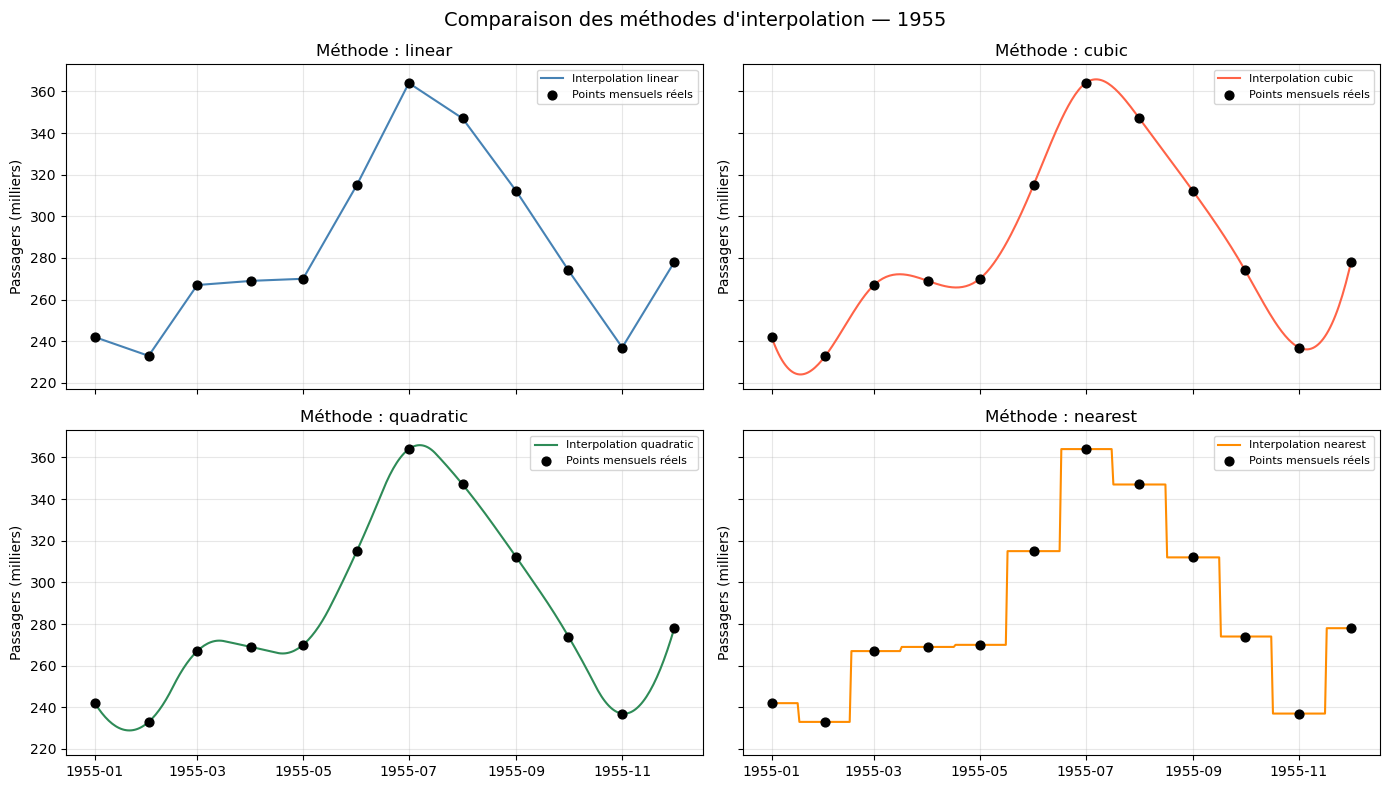

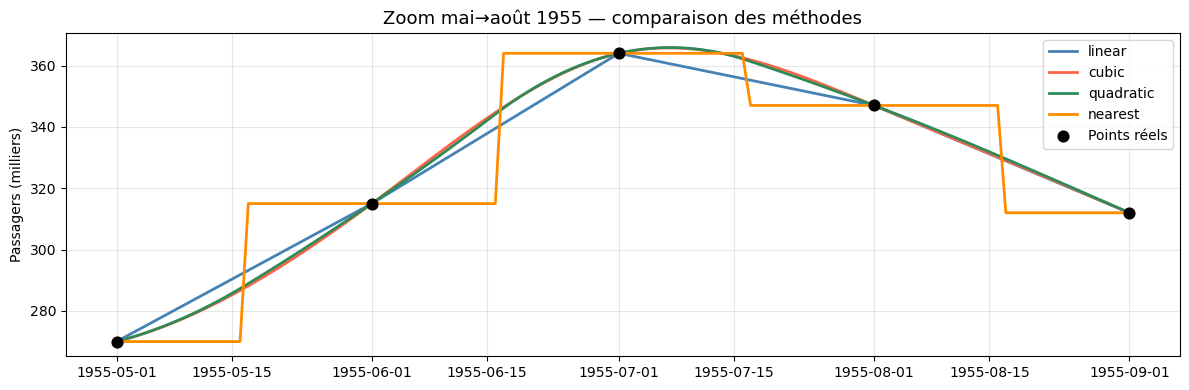

In [18]:
# Sélection d'une année 
year = 1955
airline_year = airline[airline.index.year == year]
print(f"Série mensuelle {year} : {len(airline_year)} points")
print(airline_year)

# Resample vers fréquence journalière (crée des NaN)
airline_daily = airline_year.resample('D').mean()
print(f"\nAprès resample journalier : {len(airline_daily)} points")
print(f"NaN créés : {airline_daily.isna().sum()} / {len(airline_daily)}")

# Interpolation avec différentes méthodes 
interp_linear    = airline_daily.interpolate(method='linear')
interp_cubic     = airline_daily.interpolate(method='cubic')
interp_quadratic = airline_daily.interpolate(method='quadratic')
interp_nearest   = airline_daily.interpolate(method='nearest')

# Visualisation 
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

methods = [
    (interp_linear,    'linear',    'steelblue'),
    (interp_cubic,     'cubic',     'tomato'),
    (interp_quadratic, 'quadratic', 'seagreen'),
    (interp_nearest,   'nearest',   'darkorange'),
]

for ax, (serie, name, color) in zip(axes, methods):
    # Courbe interpolée
    ax.plot(serie.index, serie.values,
            color=color, linewidth=1.5, label=f'Interpolation {name}')
    # Points originaux mensuels (les points connus)
    ax.scatter(airline_year.index, airline_year.values,
               color='black', zorder=5, s=40, label='Points mensuels réels')
    ax.set_title(f'Méthode : {name}', fontsize=12)
    ax.set_ylabel('Passagers (milliers)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Comparaison des méthodes d'interpolation — {year}", fontsize=14)
plt.tight_layout()
plt.show()

#  Zoom sur un intervalle court pour voir les différences 
fig, ax = plt.subplots(figsize=(12, 4))
zoom_start = f'{year}-05-01'
zoom_end   = f'{year}-09-01'

for serie, name, color in methods:
    ax.plot(serie[zoom_start:zoom_end],
            color=color, linewidth=2, label=name)

ax.scatter(airline_year[zoom_start:zoom_end].index,
           airline_year[zoom_start:zoom_end].values,
           color='black', zorder=5, s=60, label='Points réels')

ax.set_title(f'Zoom mai→août {year} — comparaison des méthodes', fontsize=13)
ax.set_ylabel('Passagers (milliers)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Identifying patterns: Trend & Seasonality

**Theory**

To analyze, and eventually forecast, a time series, it is useful to break it down into simple components. Typically, a time series is modeled as the contribution of three components:
- The Trend $T$: long-term movement or direction of the time series, related to the underlying growth or decline such as in upward, downward or flat trend
- The Seasonality $S$: repeating patterns or fluctuations that occur in a time series at regular intervals, such as daily, weekly, monthly, or yearly patterns
- The Residuals $R$: residual random variations or noise that cannot be explained by the trend and seasonality

Decomposing the signal into these components is useful for
- Removing noise arising from measurement errors or random fluctuations
- Isolate trend and seasonality to model and analyze them separately
- Make better forecasts

There are two main types of seasonal decomposition: the **additive** and **multiplicative** decomposition.
The additive model tries to find the best possible components $T_t$, $S_t$, $R_t$ such that at all times $t$ the serie $Y_t$ is decomposed as
$$ Y_t = T_t + S_t + R_t$$  
The additive model is linear since the variations of the trend and seasonality are independent of each other. When the seasonal (periodic) variations in the time serie seem to be independent of the trend, additive models are preferred. 

Conversely, the multiplicative model tries to find the best possible components $T_t$, $S_t$, $R_t$ such that at all times $t$ the serie $Y_t$ is decomposed as
$$ Y_t = T_t * S_t * R_t$$
Note that the multiplicative model can be seen as an additive model in log-space, i.e. it is completely equivalent to
$$ \log Y_t = \log T_t + \log S_t + \log R_t$$
Multiplicatrive models are non linear since the variations in the trend imply variations in seasonality, and vice-versa. When the seasonal variations in the time series seems to change with time, multiplicative models are preferred.

--------------------

**Resources**

- https://medium.com/analytics-vidhya/time-series-decomposition-part-i-trend-cycle-computation-29fac227896a
- https://otexts.com/fpp2/components.html
- https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html<br/>
- https://towardsdatascience.com/time-series-analysis-resampling-shifting-and-rolling-f5664ddef77e

--------------------

**TODO**

Back to the monthly dataset (do not continue with the interpolated one).
- Use the function `seasonal_decompose()` from Statmodels to decompose the dataset into its components with both an additive and multiplicative model.
- Visualize the results. Which model works best ?
- Perform your own decomposition using the `rolling()` method from Pandas.

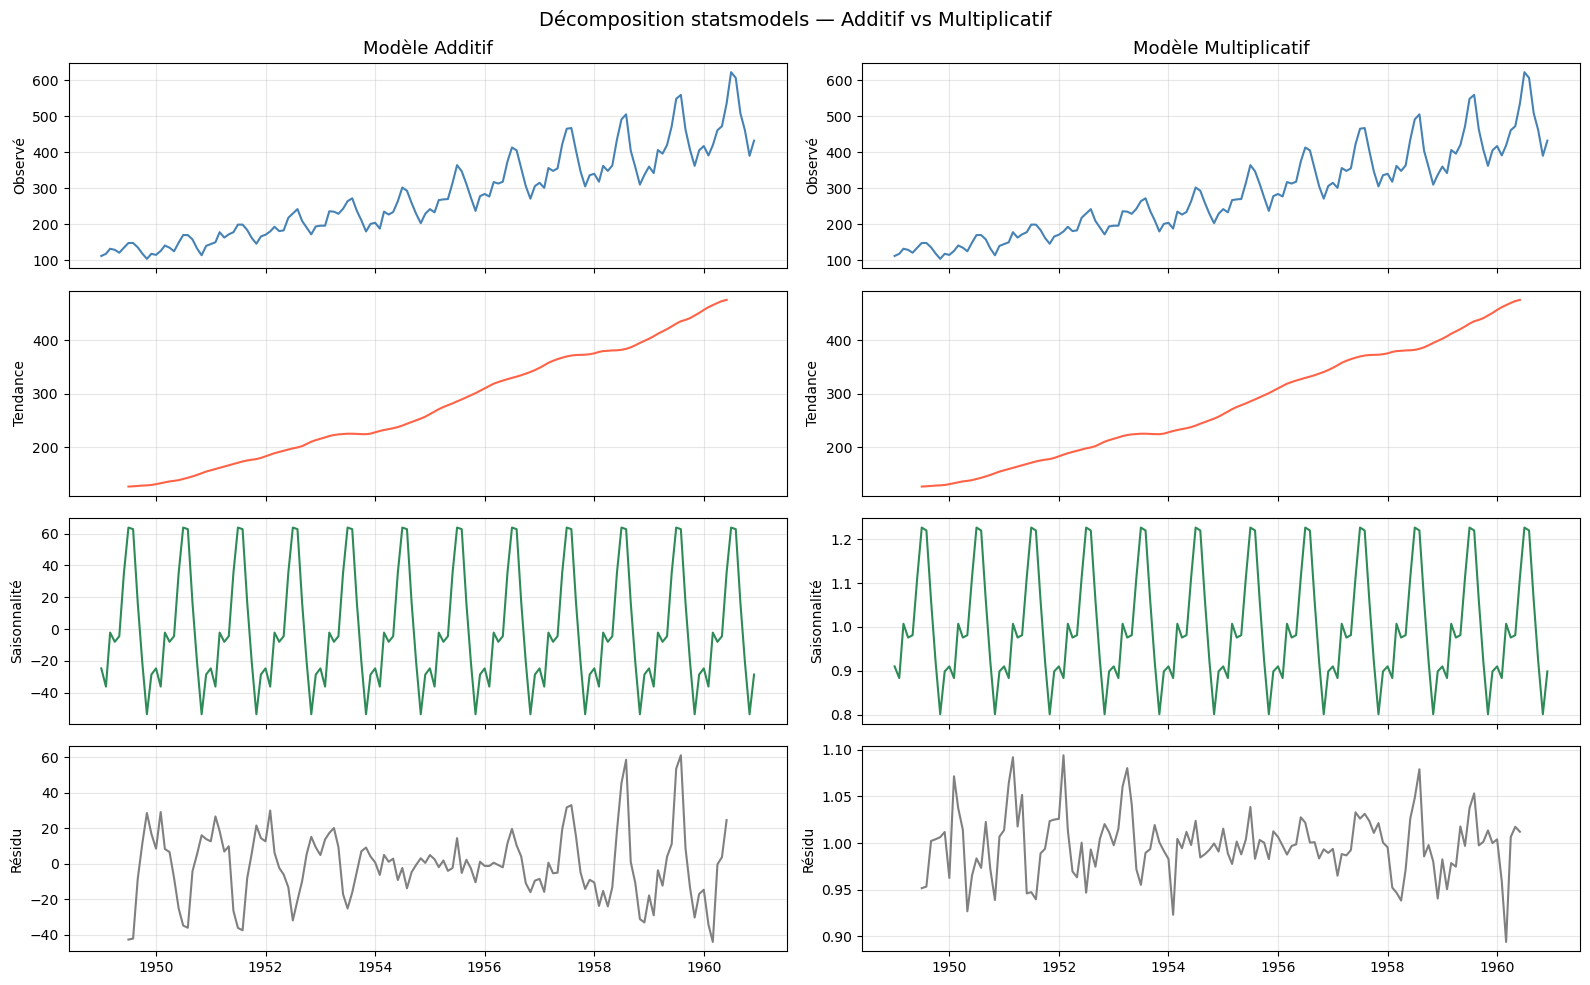

In [27]:
# Décomposition statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

# Your code here
decomp_add  = seasonal_decompose(airline, model='additive',      period=12)
decomp_mult = seasonal_decompose(airline, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)

for col, (decomp, name) in enumerate([(decomp_add, 'Additif'),
                                       (decomp_mult, 'Multiplicatif')]):
    axes[0][col].plot(decomp.observed,  color='steelblue')
    axes[0][col].set_ylabel('Observé')
    axes[0][col].set_title(f'Modèle {name}', fontsize=13)

    axes[1][col].plot(decomp.trend,     color='tomato')
    axes[1][col].set_ylabel('Tendance')

    axes[2][col].plot(decomp.seasonal,  color='seagreen')
    axes[2][col].set_ylabel('Saisonnalité')

    axes[3][col].plot(decomp.resid,     color='gray')
    axes[3][col].set_ylabel('Résidu')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

plt.suptitle("Décomposition statsmodels — Additif vs Multiplicatif", fontsize=14)
plt.tight_layout()
plt.show()


In [21]:
# Inspecter les résidus pour choisir le meilleur modèle 
print("=== Analyse des résidus ===\n")
for decomp, name in [(decomp_add, 'Additif'), (decomp_mult, 'Multiplicatif')]:
    resid = decomp.resid.dropna()
    print(f"Modèle {name}:")
    print(f"  Moyenne  : {resid.mean():.4f}  (idéal → 0)")
    print(f"  Std      : {resid.std():.4f}")
    print(f"  Min/Max  : {resid.min():.3f} / {resid.max():.3f}\n")

=== Analyse des résidus ===

Modèle Additif:
  Moyenne  : -0.7513  (idéal → 0)
  Std      : 19.3405
  Min/Max  : -43.967 / 61.052

Modèle Multiplicatif:
  Moyenne  : 0.9982  (idéal → 0)
  Std      : 0.0334
  Min/Max  : 0.894 / 1.094



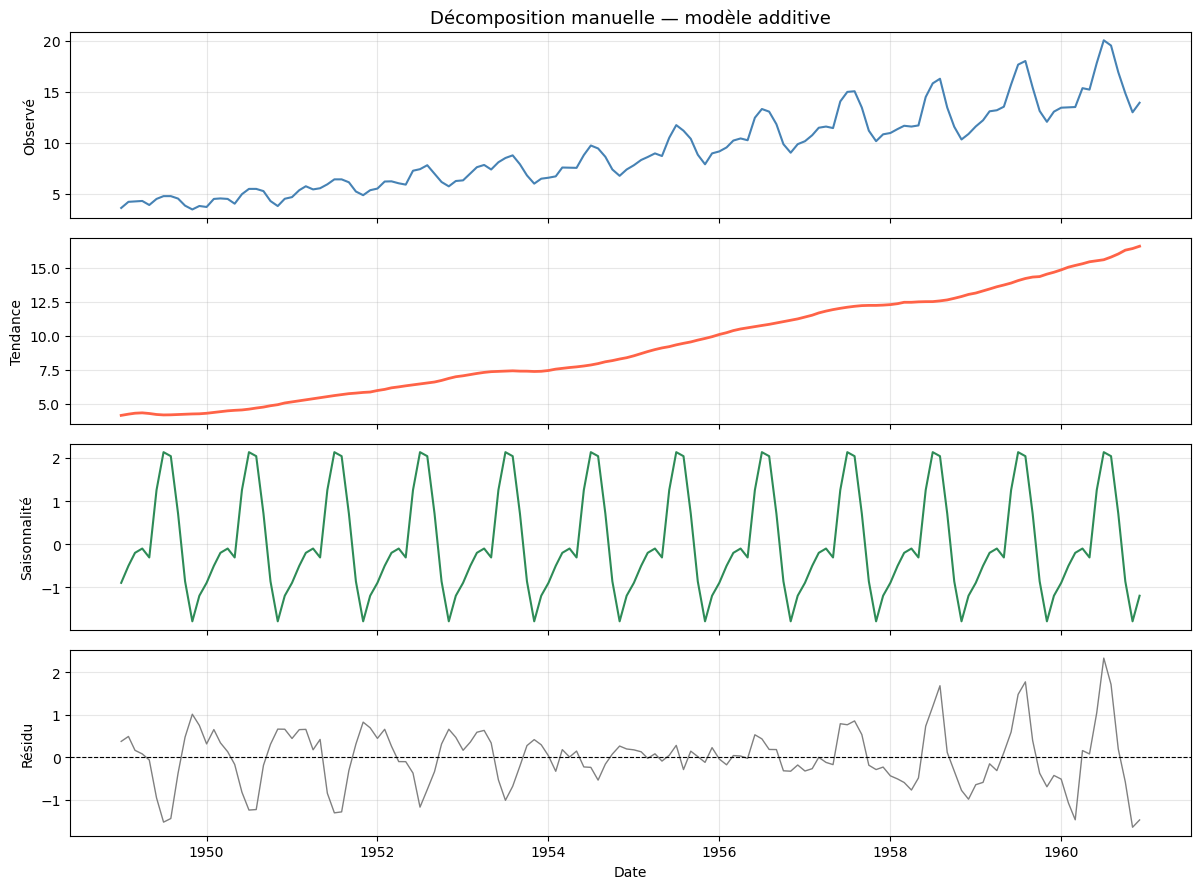

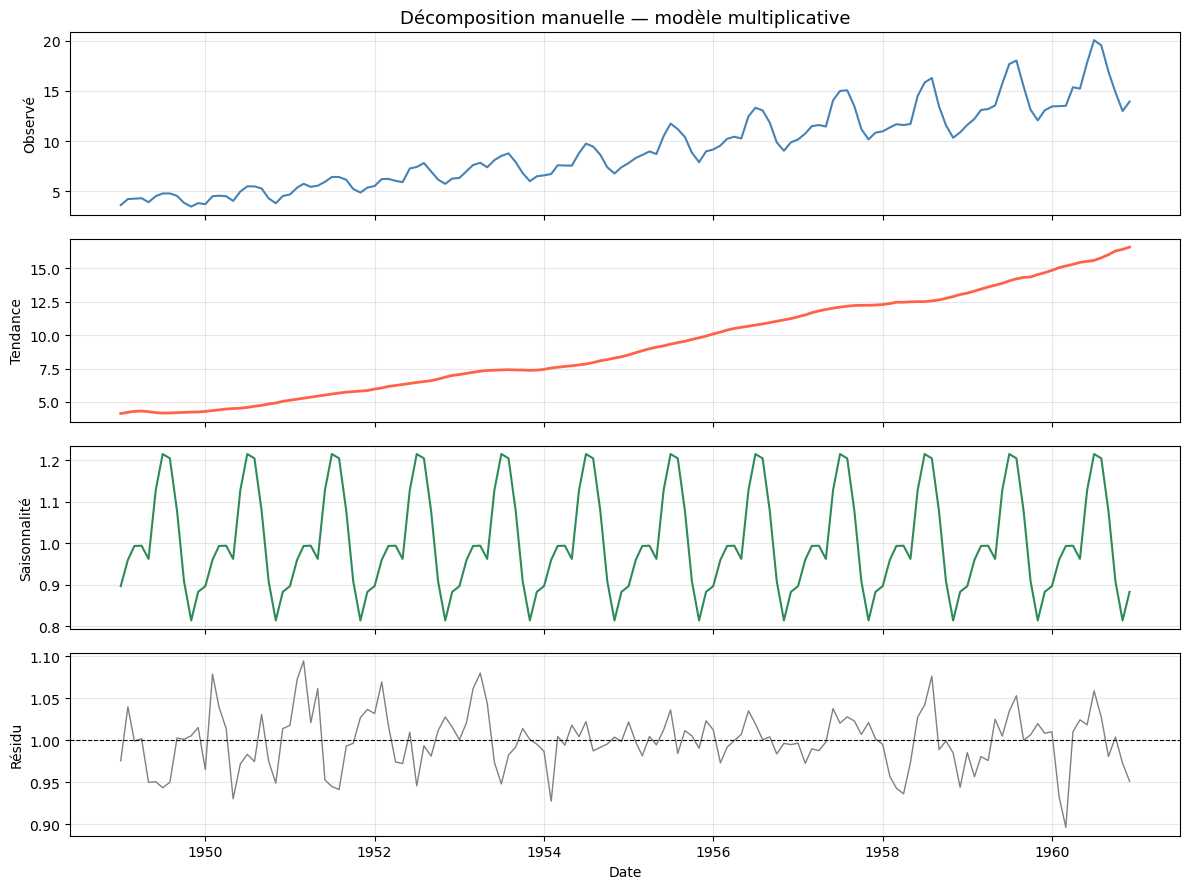

In [ ]:

# Décomposition manuelle avec rolling() 

def monthly_average(data):
    avg = data.groupby(data.index.month).mean()
    index = pd.date_range(START_DATE, periods=len(data), freq='MS')
    result = np.zeros(len(index))
    for i, n in enumerate(index):
        result[i] = avg[n.month]
    return pd.Series(data=result, index=index)


def custom_seasonal(data, model='additive'):
    # ── Étape 1 : Tendance = moyenne mobile centrée sur 12 mois 
    # window=13 + center=True + min_periods=1 est une approximation courante
    # On divise par 2 les extrémités pour centrer proprement (2×12 = 24)
    trend = data.rolling(window=12, center=True, min_periods=6).mean()

    if model == 'additive':
        # ── Étape 2 : Série détrended = Série - Tendance 
        detrended = data - trend
        # ── Étape 3 : Saisonnalité = moyenne par mois sur le détrended 
        seasonal = monthly_average(detrended)
        # ── Étape 4 : Résidu = ce qui reste après trend + seasonal 
        residual = data - trend - seasonal

    elif model == 'multiplicative':
        # ── Étape 2 : Série détrended = Série / Tendance 
        detrended = data / trend
        # ── Étape 3 : Saisonnalité = moyenne par mois sur le détrended 
        seasonal = monthly_average(detrended)
        # ── Étape 4 : Résidu = ce qui reste après trend * seasonal 
        residual = data / (trend * seasonal)

    else:
        raise ValueError('Unknown model name')

    # ── Visualisation 
    fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 9))

    axes[0].plot(data,     color='steelblue', linewidth=1.5)
    axes[0].set_ylabel('Observé')
    axes[0].set_title(f'Décomposition manuelle — modèle {model}', fontsize=13)

    axes[1].plot(trend,    color='tomato',    linewidth=2)
    axes[1].set_ylabel('Tendance')

    axes[2].plot(seasonal, color='seagreen',  linewidth=1.5)
    axes[2].set_ylabel('Saisonnalité')

    axes[3].plot(residual, color='gray',      linewidth=1)
    axes[3].axhline(y=1 if model == 'multiplicative' else 0,
                    color='black', linestyle='--', linewidth=0.8)
    axes[3].set_ylabel('Résidu')
    axes[3].set_xlabel('Date')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return trend, seasonal, residual


# Lancer les deux modèles
trend_a, seasonal_a, residual_a = custom_seasonal(airline_adj, model='additive')
trend_m, seasonal_m, residual_m = custom_seasonal(airline_adj, model='multiplicative')

# 3. Stationarity

### 3.1 Stationarity & Heteroskedasticity

**Theory**

A time series is a series of data points indexed in time. The fact that time series data are ordered makes them unique in the data space, as they often display serial dependency. Serial dependence occurs when the value of a data point at one point in time is statistically dependent on another data point at another point in time. However, this attribute of time series data violates one of the fundamental assumptions of many statistical analyses - that the data are statistically independent (Independent & Identically Distributed, IID, see https://en.wikipedia.org/wiki/Independent_and_identically_distributed_random_variables) !

Thus, we often need to assess some less restricting properties in order to deal (and model) time series. A time series is said to be *stationary* when its properties (such as the mean, the variance, the autocorrelation, etc...) do not change over time. This is a very useful property because it is the assumption underlying many predictive models in time series forecasting. Trends can result in a varying mean over time, whereas seasonality can result in a changing variance over time, and both will result in a non-stationary time serie. Specifically, *heteroskedasticity* refers to the property of having a non-constant variance. Thus, if a time serie is heteroskedastic, it is not stationary!

**Resources**
- https://towardsdatascience.com/stationarity-in-time-series-analysis-90c94f27322
- https://www.analyticsvidhya.com/blog/2021/06/statistical-tests-to-check-stationarity-in-time-series-part-1/

**TODO**
- Plot the time serie along with is rolling mean and variance.
- Is this time serie stationary or not? Why ?
- What about heteroskedasticity?

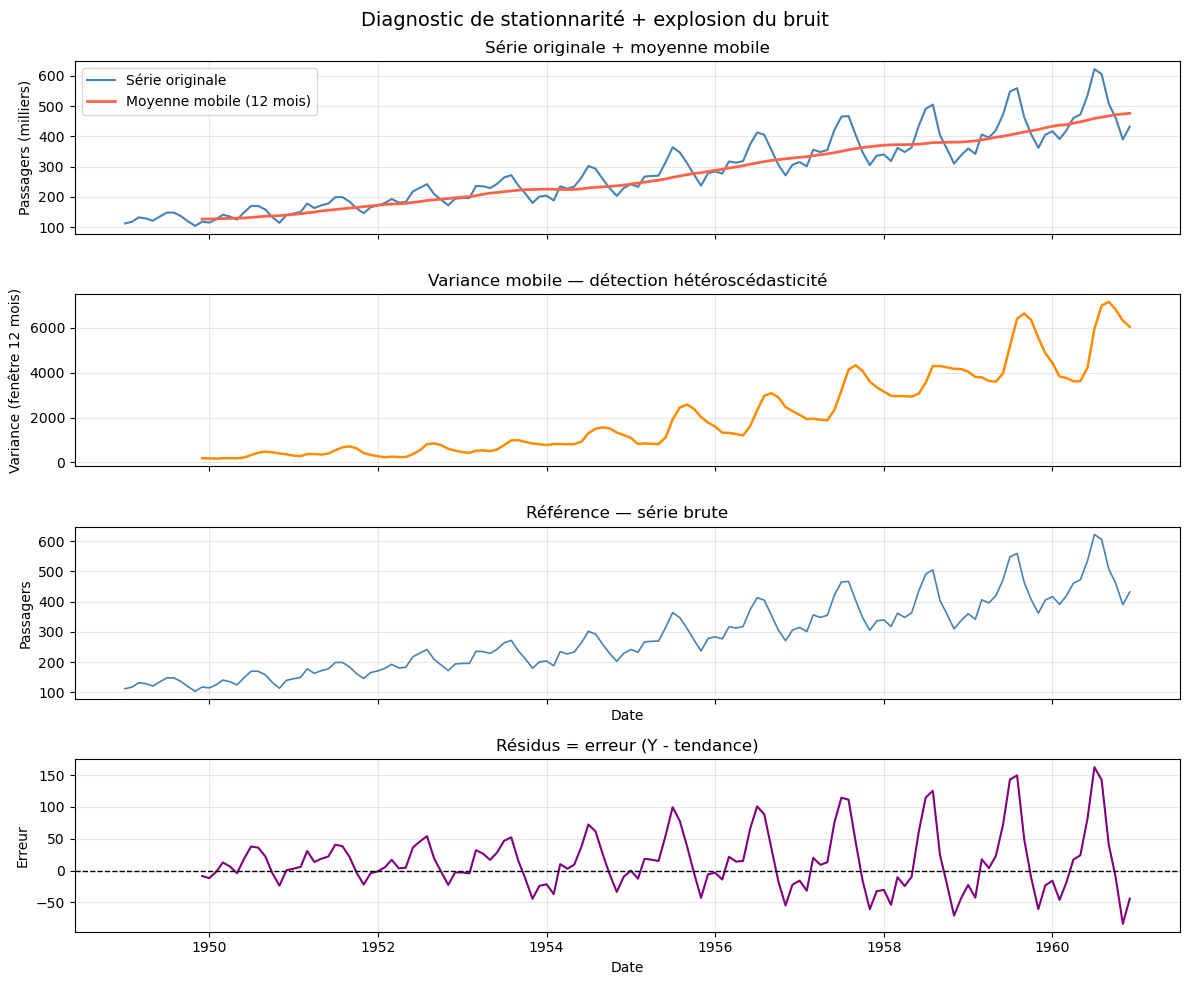

In [34]:
# Plot1: Combined Plot to assess
# - "Passengers"
# - "Rolling mean"
# - "Rolling standard deviation"

window = 12  # fenêtre de 12 mois = 1 an

rolling_mean = airline.rolling(window=window).mean()
rolling_var  = airline.rolling(window=window).var()

# Erreur (résidu approximé)
residuals = airline - rolling_mean
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Série + moyenne mobile
axes[0].plot(airline,       color='steelblue', linewidth=1.5, label='Série originale')
axes[0].plot(rolling_mean,  color='tomato',    linewidth=2,   label=f'Moyenne mobile ({window} mois)')
axes[0].set_ylabel('Passagers (milliers)')
axes[0].set_title('Série originale + moyenne mobile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variance mobile
axes[1].plot(rolling_var, color='darkorange', linewidth=1.8)
axes[1].set_ylabel('Variance (fenêtre 12 mois)')
axes[1].set_title('Variance mobile — détection hétéroscédasticité')
axes[1].grid(True, alpha=0.3)

# Série originale seule pour référence visuelle
axes[2].plot(airline, color='steelblue', linewidth=1.2)
axes[2].set_ylabel('Passagers')
axes[2].set_title('Référence — série brute')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)


# 4. Résidus (erreurs)
axes[3].plot(residuals, color='purple', linewidth=1.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Erreur')
axes[3].set_title("Résidus = erreur (Y - tendance)")
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Diagnostic de stationnarité + explosion du bruit', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Diagnostic chiffré 
print("=== Diagnostic stationnarité ===\n")
# Découper en 3 sous-périodes et comparer moyenne/variance
thirds = np.array_split(airline, 3)
labels = ['1949-1952', '1953-1956', '1957-1960']
for label, part in zip(labels, thirds):
    print(f"{label}  →  moyenne = {part.mean():.1f}   variance = {part.var():.1f} std = {np.sqrt(part.var()):.1f}")

=== Diagnostic stationnarité ===

1949-1952  →  moyenne = 158.4   variance = 1094.7 std = 33.1
1953-1956  →  moyenne = 269.0   variance = 3106.0 std = 55.7
1957-1960  →  moyenne = 413.5   variance = 6162.0 std = 78.5


/home/youssef.hirchaou@Digital-Grenoble.local/anaconda3/envs/timeseries/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


### 3.2 Differencing

If the time series at hand is not stationary, we can apply some transformations to make it stationary. The difference transform helps stabilizing the mean of the time series by removing changes in the level of a time series, and so eliminating (or reducing) trend and seasonality. For a time series $Y_t$, its (first-order) difference $D_t$ is defined as
$$D_t = Y_t - Y_{t-1}$$
If you apply this difference transform iteratively, you can achieve what is called $n^{th}$-order differentiation!

**TODO**
- Write a function to compute the first-order difference of the time series and plot it.
- Check your results by comparing to Pandas `.diff()` method.
- What can you say about the trend and the seasonality ?
- What about heteroskedasticity ?

In [55]:
def difference(data, lag=1):
    # Compute the difference series
    diff = data - data.shift(lag)
    return diff
    
# Compute difference and plot
diff1_manual = difference(airline, lag=1)
diff1_pandas  = airline.diff(1)

# Compare with Pandas
print("Différence ordre 1 — vérification (5 premières valeurs) :")
print(pd.DataFrame({'Manuel': diff1_manual.head(), 'Pandas': diff1_pandas.head()}))
print(f"Identiques : {np.allclose(diff1_manual.dropna(), diff1_pandas.dropna())}\n")


Différence ordre 1 — vérification (5 premières valeurs) :
            Manuel  Pandas
1949-01-01     NaN     NaN
1949-02-01     6.0     6.0
1949-03-01    14.0    14.0
1949-04-01    -3.0    -3.0
1949-05-01    -8.0    -8.0
Identiques : True



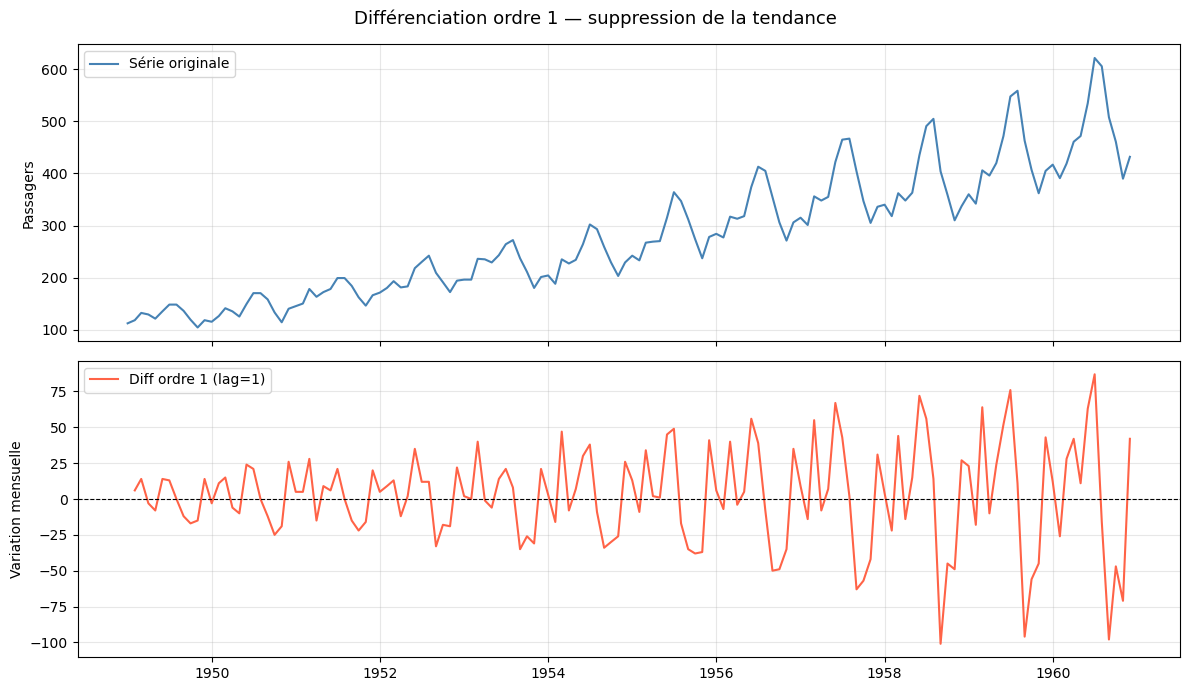

In [42]:
# ── Visualisation différence ordre 1
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(airline,       color='steelblue', linewidth=1.5, label='Série originale')
axes[0].set_ylabel('Passagers') ; axes[0].legend() ; axes[0].grid(True, alpha=0.3)
axes[1].plot(diff1_manual,  color='tomato',    linewidth=1.5, label='Diff ordre 1 (lag=1)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Variation mensuelle') ; axes[1].legend() ; axes[1].grid(True, alpha=0.3)
plt.suptitle('Différenciation ordre 1 — suppression de la tendance', fontsize=13)
plt.tight_layout()
plt.show()

Differencing can also be used to remove seasonality. In the above equations, we defined $D_t$ as the difference between two *consecutive*  values of the time series. But we can also take the difference on a larger interval of time, called the lag, $l$:
$$ D_t = Y_t - Y_{t-l}$$
where $l$ can be any integer $>1$. If we set $l$ to match the cyclic pattern of our time series, then we expect the difference transform to eliminate the seasonality. Let's try this out!

In [ ]:
# ── Différence saisonnière (lag=12)
lag = 12
diff12_manual = difference(airline, lag=lag)
diff12_pandas  = airline.diff(lag)

print(f"Différence lag={lag} — vérification (quelques valeurs) :")
print(pd.DataFrame({'Manuel': diff12_manual.head(15).tail(5),
                    'Pandas': diff12_pandas.head(15).tail(5)}))
print(f"Identiques : {np.allclose(diff12_manual.dropna(), diff12_pandas.dropna())}\n")


Différence lag=12 — vérification (quelques valeurs) :
            Manuel  Pandas
1949-11-01     NaN     NaN
1949-12-01     NaN     NaN
1950-01-01     3.0     3.0
1950-02-01     8.0     8.0
1950-03-01     9.0     9.0
Identiques : True



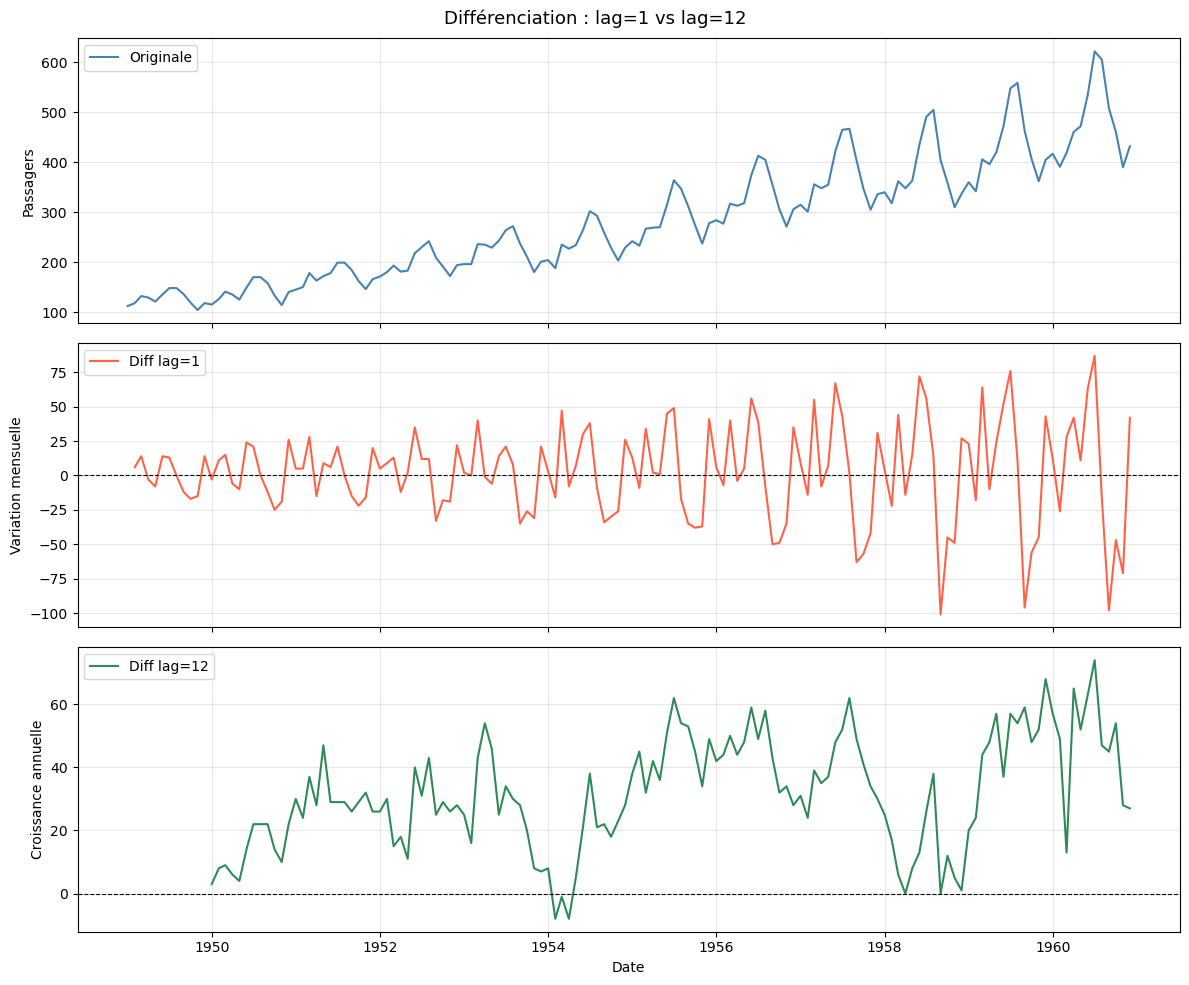

In [45]:

# Visualisation différence saisonnière 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(airline,      color='steelblue', linewidth=1.5, label='Originale')
axes[0].set_ylabel('Passagers') ; axes[0].legend() ; axes[0].grid(True, alpha=0.3)

axes[1].plot(diff1_manual, color='tomato',    linewidth=1.5, label='Diff lag=1')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Variation mensuelle') ; axes[1].legend() ; axes[1].grid(True, alpha=0.3)

axes[2].plot(diff12_manual,color='seagreen',  linewidth=1.5, label='Diff lag=12')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Croissance annuelle') ; axes[2].legend() ; axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Date')

plt.suptitle('Différenciation : lag=1 vs lag=12', fontsize=13)
plt.tight_layout()
plt.show()

In [46]:
# ── Analyse des résultats 
print("=== Analyse des différenciations ===\n")
for serie, name in [(diff1_manual.dropna(),  'Diff lag=1'),
                    (diff12_manual.dropna(), 'Diff lag=12')]:
    print(f"{name}:")
    print(f"  Moyenne  : {serie.mean():.3f}")
    print(f"  Variance : {serie.var():.3f}")
    print(f"  Std      : {serie.std():.3f}\n")

=== Analyse des différenciations ===

Diff lag=1:
  Moyenne  : 2.238
  Variance : 1139.352
  Std      : 33.754

Diff lag=12:
  Moyenne  : 31.773
  Variance : 311.688
  Std      : 17.655



### 3.3 Log-transform

We will see that ARIMA models can take into account an increasing mean over time, but not the variance. In this case, we specifically want to get rid of the heteroskedasticity. To this aim, a very common operation is to apply a log transform.

The log transform is very simple, it's just $\tilde{Y}_t = \log Y_t$.

**TODO**
- Compute the log transform of the time series and plot it.
- Is it stationary ?

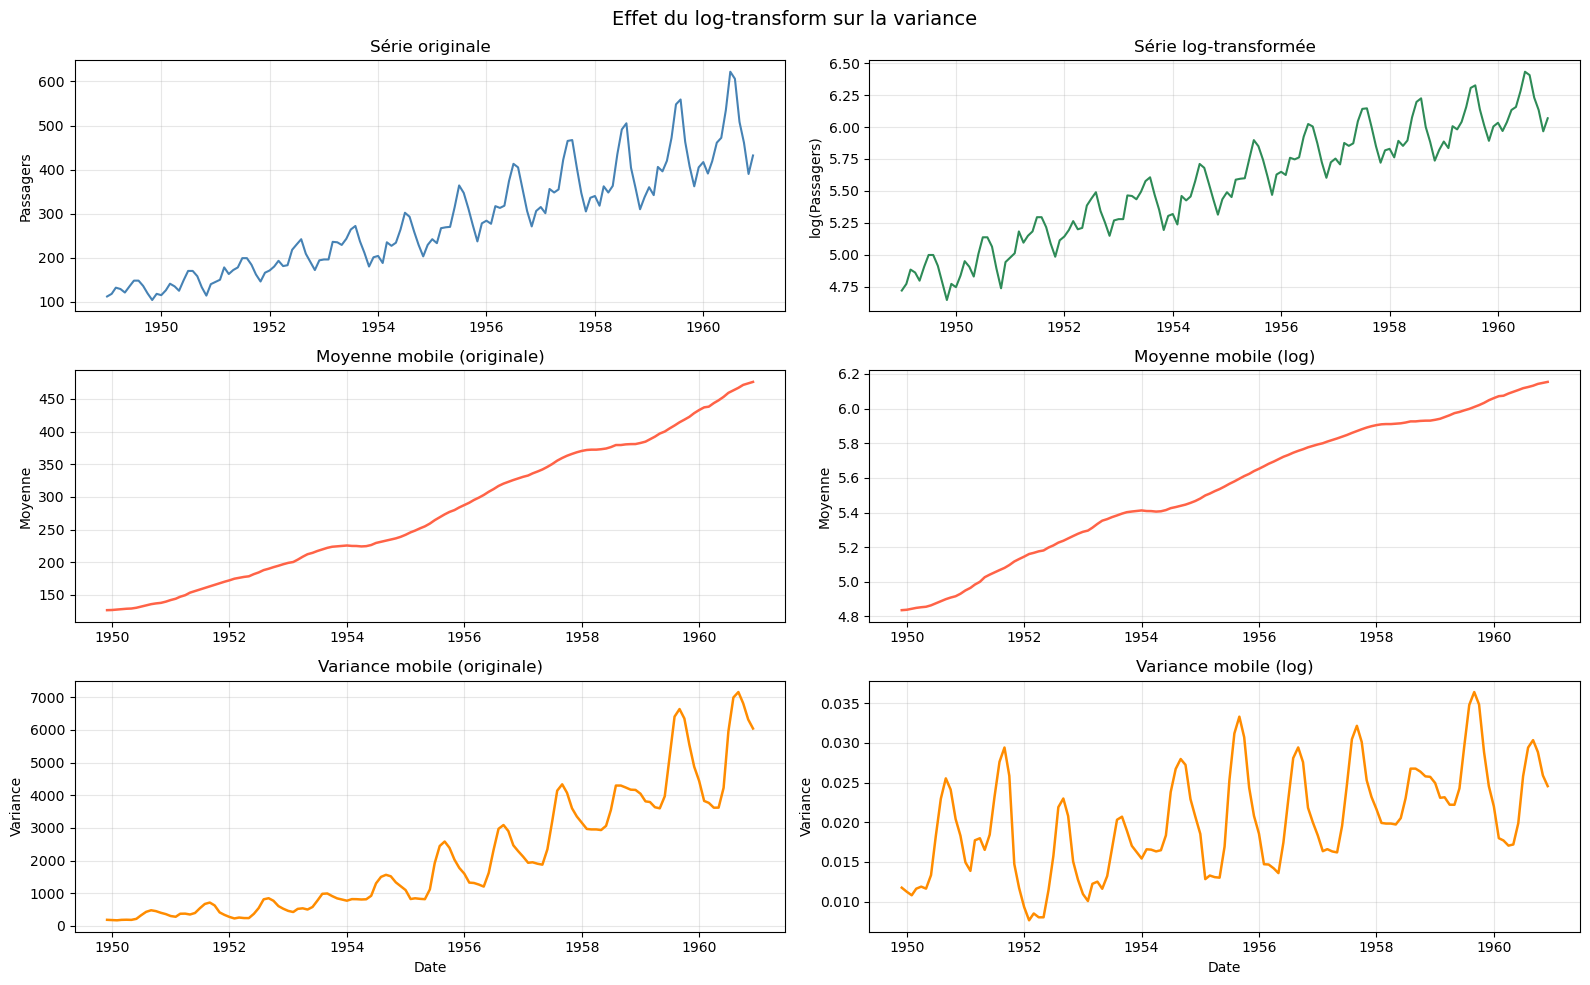

=== Effet du log sur l'hétéroscédasticité ===

Période        Var originale      Var log
------------------------------------------
1949-1952             1094.7       0.0429
1953-1956             3106.0       0.0405
1957-1960             6162.0       0.0334


In [ ]:
# Compute log transform and show the plot
# ── Log-transform 
airline_log = np.log(airline)

# ── Moyenne et variance mobiles sur la série log 
log_rolling_mean = airline_log.rolling(window=12).mean()
log_rolling_var  = airline_log.rolling(window=12).var()

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# Colonne gauche : série originale
axes[0][0].plot(airline,      color='steelblue', linewidth=1.5)
axes[0][0].set_title('Série originale')
axes[0][0].set_ylabel('Passagers')
axes[0][0].grid(True, alpha=0.3)

axes[1][0].plot(rolling_mean, color='tomato',    linewidth=1.8)
axes[1][0].set_title('Moyenne mobile (originale)')
axes[1][0].set_ylabel('Moyenne')
axes[1][0].grid(True, alpha=0.3)

axes[2][0].plot(rolling_var,  color='darkorange', linewidth=1.8)
axes[2][0].set_title('Variance mobile (originale)')
axes[2][0].set_ylabel('Variance')
axes[2][0].set_xlabel('Date')
axes[2][0].grid(True, alpha=0.3)

# Colonne droite : série log
axes[0][1].plot(airline_log,      color='seagreen', linewidth=1.5)
axes[0][1].set_title('Série log-transformée')
axes[0][1].set_ylabel('log(Passagers)')
axes[0][1].grid(True, alpha=0.3)

axes[1][1].plot(log_rolling_mean, color='tomato',   linewidth=1.8)
axes[1][1].set_title('Moyenne mobile (log)')
axes[1][1].set_ylabel('Moyenne')
axes[1][1].grid(True, alpha=0.3)

axes[2][1].plot(log_rolling_var,  color='darkorange', linewidth=1.8)
axes[2][1].set_title('Variance mobile (log)')
axes[2][1].set_ylabel('Variance')
axes[2][1].set_xlabel('Date')
axes[2][1].grid(True, alpha=0.3)

plt.suptitle('Effet du log-transform sur la variance', fontsize=14)
plt.tight_layout()
plt.show()

# ── Comparaison chiffrée 
print("=== Effet du log sur l'hétéroscédasticité ===\n")
thirds_log = np.array_split(airline_log, 3)
labels = ['1949-1952', '1953-1956', '1957-1960']
print(f"{'Période':<12} {'Var originale':>15} {'Var log':>12}")
print("-" * 42)
for label, part_orig, part_log in zip(labels, thirds, thirds_log):
    print(f"{label:<12} {part_orig.var():>15.1f} {part_log.var():>12.4f}")



### 3.4 Putting it all together

You now know how to detrend a dataset and how to tame heteroskedasticity. Let's see if we can use and combine these tools to make our time series stationary. To check if the transformed serie is indeed stationary, you can use two different stationarity tests: the *Augmented Dickey Fuller (ADF)* test and the *Kwiatkowski-Phillips-Schmidt-Shin (KPSS)* test.
Note that the Null Hypothesis of the ADF test is that the serie is non-stationary, whereas the Null Hypothesis of the KPSS test is that the serie is stationary!


**TODO**
- Apply the log transform and differentiate the time series. Does the order matter ? Why ?
- Plot the transformed time serie along with is rolling mean and variance. What do you observe ?
- Perform the ADF and KPSS tests before and after your transformation. Is the transformed time serie stationary ?

In [ ]:
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.stattools import kpss

# def adf_test(timeseries):
#     print("Results of Dickey-Fuller Test:")
#     dftest = adfuller(timeseries, autolag="AIC")
#     dfoutput = pd.Series(
#         dftest[0:4],
#         index=[
#             "Test Statistic",
#             "p-value",
#             "#Lags Used",
#             "Number of Observations Used",
#         ],
#     )
#     for key, value in dftest[4].items():
#         dfoutput["Critical Value (%s)" % key] = value
#     print(dfoutput)

# def kpss_test(timeseries):
#     print("Results of KPSS Test:")
#     kpsstest = kpss(timeseries, regression="c", nlags="auto")
#     kpss_output = pd.Series(
#         kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
#     )
#     for key, value in kpsstest[3].items():
#         kpss_output["Critical Value (%s)" % key] = value
#     print(kpss_output)

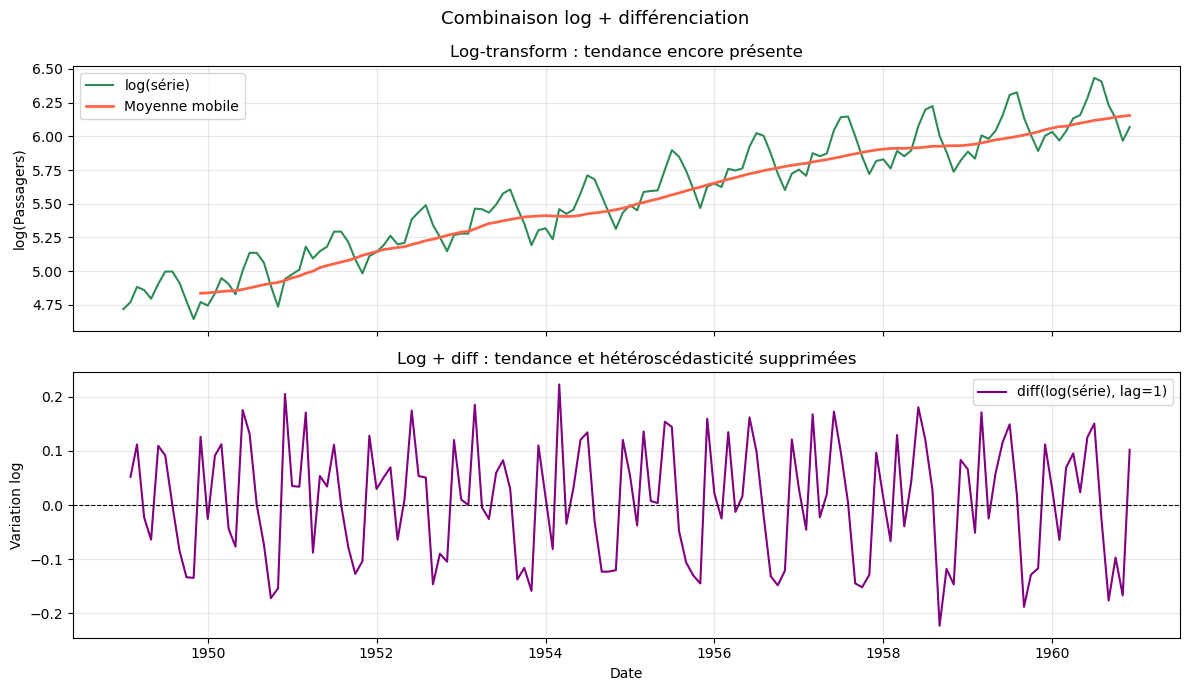

In [ ]:
# Your code here
# ── Log + diff : la combinaison gagnante 
airline_log_diff = airline_log.diff(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(airline_log,      color='seagreen', linewidth=1.5, label='log(série)')
axes[0].plot(airline_log.rolling(12).mean(), color='tomato', linewidth=2, label='Moyenne mobile')
axes[0].set_ylabel('log(Passagers)') ; axes[0].legend() ; axes[0].grid(True, alpha=0.3)
axes[0].set_title('Log-transform : tendance encore présente')

axes[1].plot(airline_log_diff, color='purple',   linewidth=1.5, label='diff(log(série), lag=1)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Variation log') ; axes[1].legend() ; axes[1].grid(True, alpha=0.3)
axes[1].set_title('Log + diff : tendance et hétéroscédasticité supprimées')
axes[1].set_xlabel('Date')

plt.suptitle('Combinaison log + différenciation', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

from statsmodels.tsa.stattools import adfuller, kpss


# Fonctions de test


def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=["Test Statistic", "p-value",
               "#Lags Used", "Number of Observations Used"],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)
    # Interprétation automatique
    p = dftest[1]
    print(f"\n→ p-value = {p:.4f} : ", end="")
    print("STATIONNAIRE ✓" if p < 0.05 else "NON STATIONNAIRE ✗")


def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3],
        index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)
    # Interprétation automatique
    p = kpsstest[1]
    print(f"\n→ p-value = {p:.4f} : ", end="")
    print("STATIONNAIRE ✓" if p > 0.05 else "NON STATIONNAIRE ✗")


def run_both_tests(series, name="Série"):
    """Lance ADF + KPSS et affiche la conclusion combinée."""
    print("=" * 55)
    print(f"  SÉRIE : {name}")
    print("=" * 55)
    adf_test(series.dropna())
    print()
    kpss_test(series.dropna())
    print()


  SÉRIE : Série brute
Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64

→ p-value = 0.9919 : NON STATIONNAIRE ✗

Results of KPSS Test:
Test Statistic           1.651312
p-value                  0.010000
Lags Used                8.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

→ p-value = 0.0100 : NON STATIONNAIRE ✗

  SÉRIE : log(série)
Results of Dickey-Fuller Test:
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5

/tmp/ipykernel_186398/1583000815.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/tmp/ipykernel_186398/1583000815.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/tmp/ipykernel_186398/1583000815.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/tmp/ipykernel_186398/1583000815.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value ret

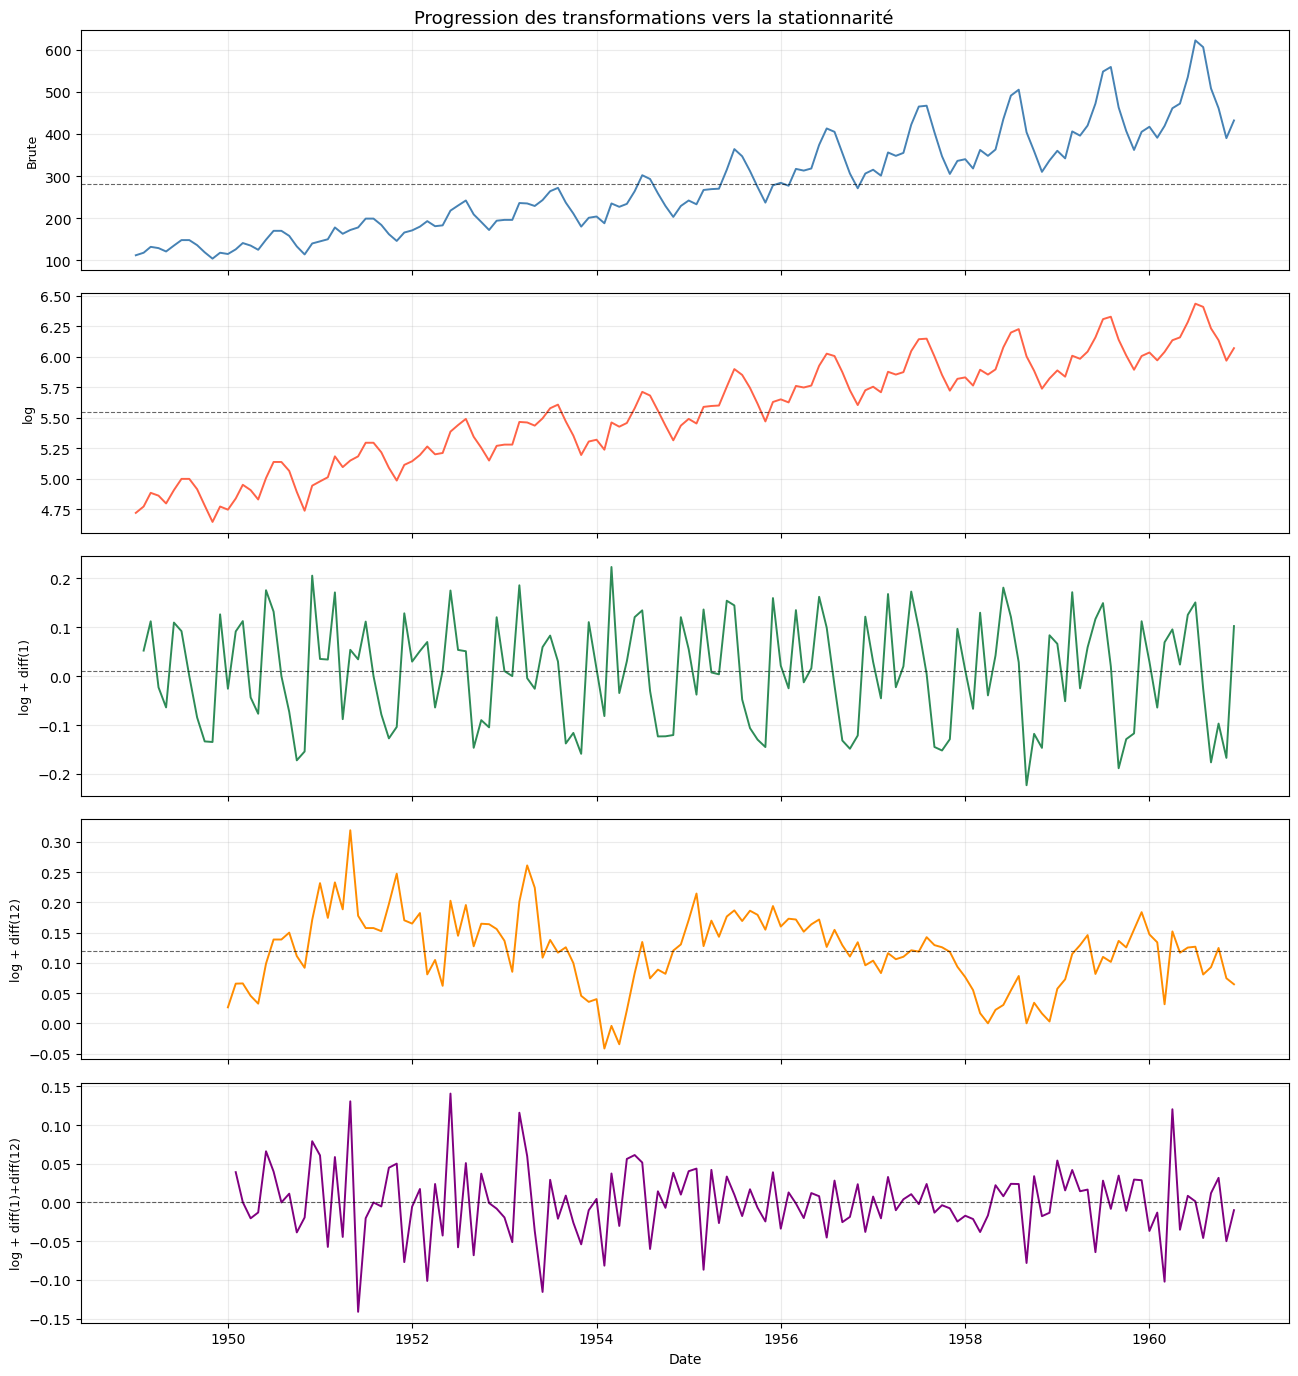

In [58]:


# Étape 1 — Série brute (référence)

run_both_tests(airline, name="Série brute")

# Étape 2 — Log-transform

airline_log = np.log(airline)
run_both_tests(airline_log, name="log(série)")


# Étape 3 — Log + différenciation ordre 1

airline_log_diff1 = airline_log.diff(1)
run_both_tests(airline_log_diff1, name="diff( log(série), lag=1 )")


# Étape 4 — Log + diff saisonnière lag=12

airline_log_diff12 = airline_log.diff(12)
run_both_tests(airline_log_diff12, name="diff( log(série), lag=12 )")


# Étape 5 — Log + diff1 + diff12 (les deux combinées)

airline_log_diff1_diff12 = airline_log.diff(1).diff(12)
run_both_tests(airline_log_diff1_diff12, name="diff( diff( log(série), 1 ), 12 )")


# Visualisation de toutes les transformations

series_to_plot = [
    (airline,                   'Brute',               'steelblue'),
    (airline_log,               'log',                 'tomato'),
    (airline_log_diff1,         'log + diff(1)',        'seagreen'),
    (airline_log_diff12,        'log + diff(12)',       'darkorange'),
    (airline_log_diff1_diff12,  'log + diff(1)+diff(12)','purple'),
]

fig, axes = plt.subplots(len(series_to_plot), 1,
                         figsize=(13, 14), sharex=True)

for ax, (serie, name, color) in zip(axes, series_to_plot):
    ax.plot(serie, color=color, linewidth=1.4)
    ax.axhline(serie.mean(), color='black',
               linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Date')
plt.suptitle('Progression des transformations vers la stationnarité',
             fontsize=13)
plt.tight_layout()
plt.show()

# 4. Auto-correlation

**Theory**

We said earlier that time series are particular because they show a serial (temporal) dependence, namely observations at a certain time $t$ are statistically correlated to previous observations. It will be useful to our analysis to measure quantitatively this serial dependence with the help of the mathematical tools of *Covariance*, *Correlation* and the related *Auto-Correlation*.

Let's first recall some definitions.
- The sample mean of $X$ is $\mu_X = \frac{1}{N} \sum_{i=1}^N X_i$ is a measure of the expected average value.
- The variance of $X$ is $V_X = \frac{1}{N} \sum_{i=1}^N (X_i - \mu_X)^2$, it is a measure of the squared deviation around the mean.
- The standard deviation of $X$ is $\sigma_X = \sqrt{V_X}$, it is a measure of the Root-Mean-Square deviation around the mean.
- The covariance of two series $X$ and $Y$ is $V(X,Y) = \frac{1}{N} \sum_{i=1}^N (X_i - \mu_X)(Y_i - \mu_Y)$, it is a measure of the joint variability of the two series.
- The correlation of two series $X$ and $Y$ is $C(X,Y) = V(X,Y) / \sigma_X \sigma_Y$, it is a measure of the statistical correlation ("Normalized Covariance") of the two series.

Finally, the Auto-Correlation Function (ACF) $ A_X(h) = C(Y_t, Y_{t-h}) $ measures for each lag $h = 1, 2, 3, ...$ the average correlation of a time series with a lagged version of itself. It measures the correlation of an observation $Y_t$ with the one $h$ time stamps before $Y_{t-h}$, on average over all the observations!

One more thing: while the ACF measures the **full** correlation between $Y$ and $Y_{t-h}$, the **Partial** Auto-Correlation Function (PACF) measures only the **direct** correlation between $Y$ and $Y_{t-h}$, by removing the contribution from the intermediate correlations. Its calculation is not unique and sometimes relies on models, so we will not say how it's calculated here.

--------------------

**Resources**
- https://towardsdatascience.com/understanding-autocorrelation-in-time-series-analysis-322ad52f2199
- https://emel333.medium.com/interpreting-autocorrelation-partial-autocorrelation-plots-for-time-series-analysis-23f87b102c64

--------------------

**TODO**
- Plot the ACF and PACF of the original &  transformed dataset (log + diff)
- Can you interpret the differences ?
- Can you find the periodicity by looking at the ACF/PACF on the transformed dataset ?

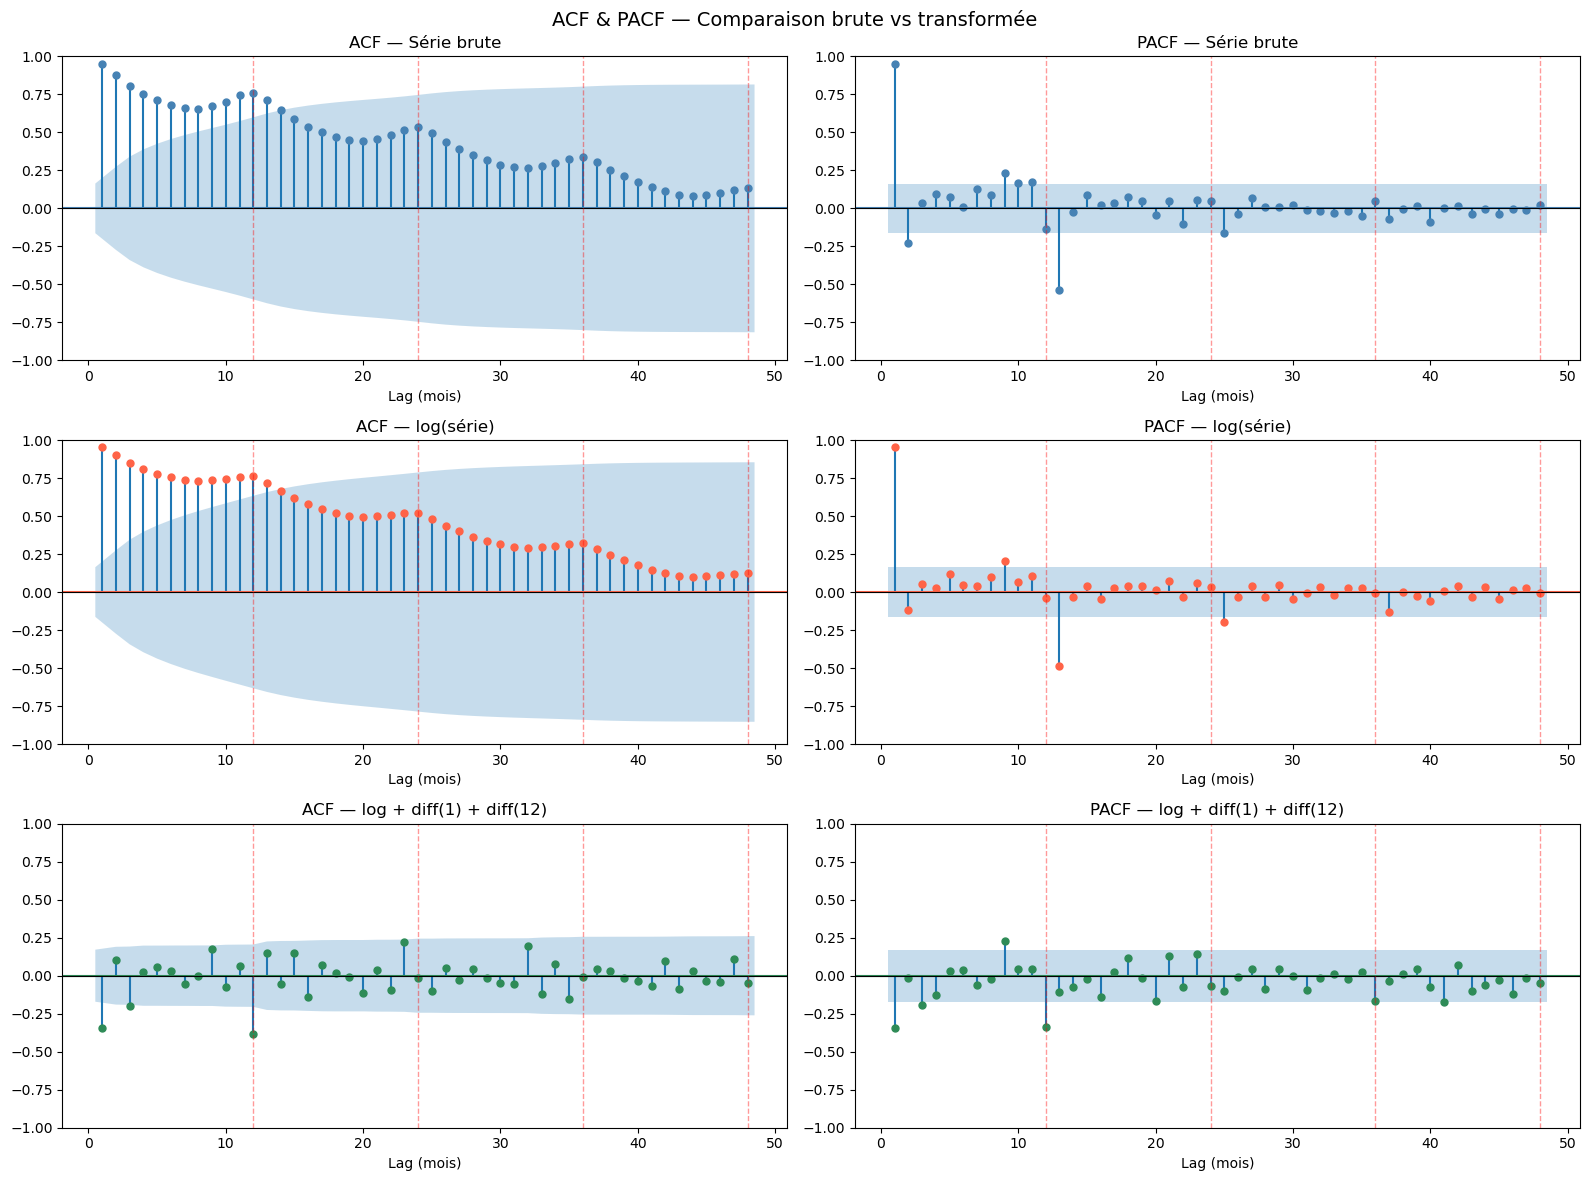

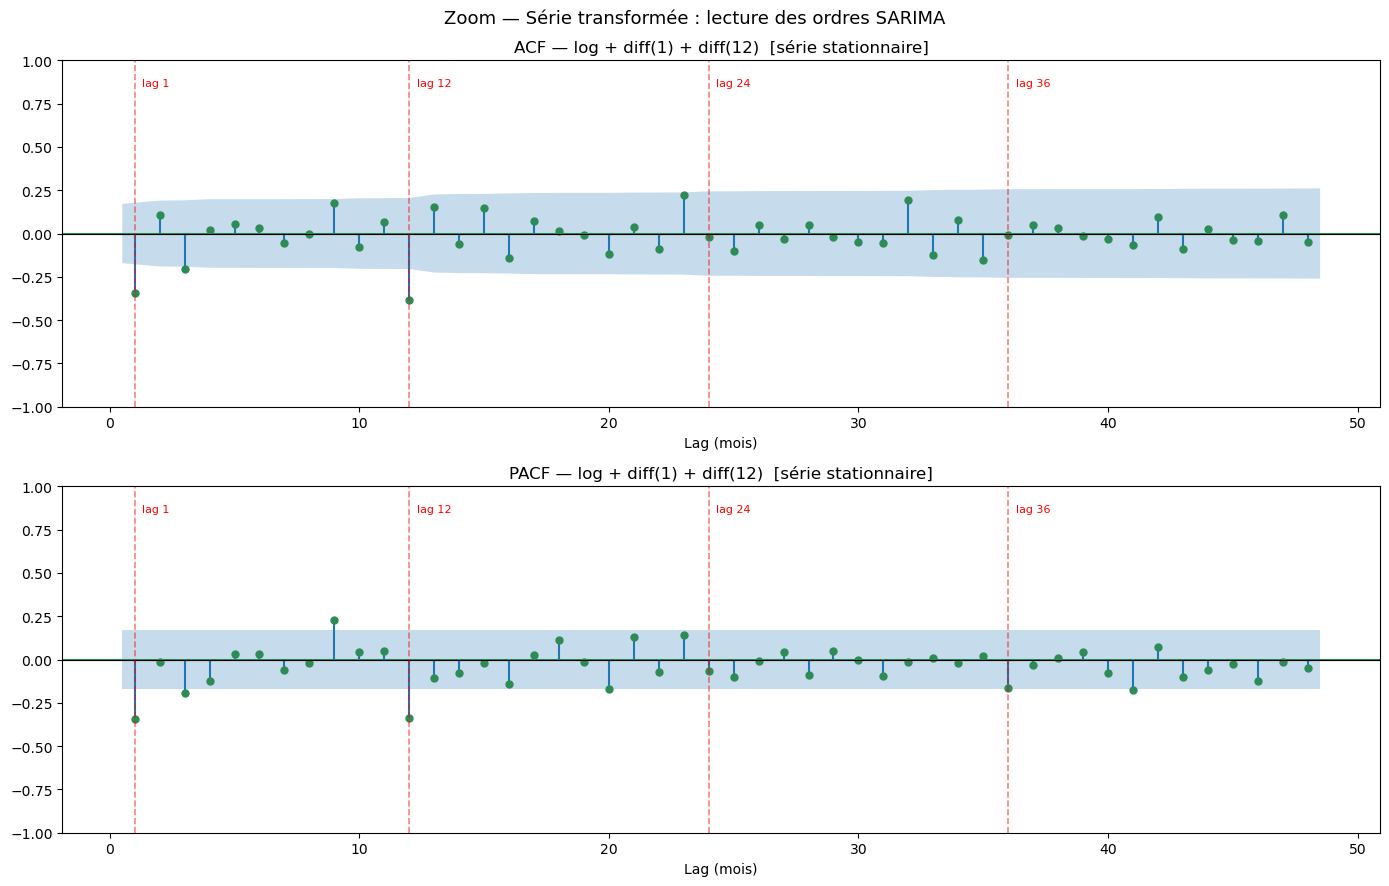


╔══════════════════════════════════════════════════════════════╗
║           LECTURE DES ORDRES SARIMA sur la série transformée ║
╠══════════════════════════════════════════════════════════════╣
║  PARTIE NON-SAISONNIÈRE (lags 1-11)                          ║
║  ACF  : pic significatif au lag 1 → composante MA(1)         ║
║  PACF : décroissance exponentielle → confirme MA             ║
║  → q = 1                                                     ║
║                                                              ║
║  PARTIE SAISONNIÈRE (lags 12, 24, 36...)                     ║
║  ACF  : pic négatif au lag 12 → composante MA saisonnière    ║
║  PACF : décroissance aux lags 12, 24... → confirme MA        ║
║  → Q = 1  (MA saisonnier d'ordre 1)                          ║
║                                                              ║
║  SPÉCIFICATION FINALE SUGGÉRÉE :                             ║
║  SARIMA (0,1,1)(0,1,1)₁₂                                    ║
║  → Modèle "Airline" de 

In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# ── Séries à analyser ─────────────────────────────────────────────────────────
airline_log           = np.log(airline)
airline_log_diff1     = airline_log.diff(1)
airline_log_diff12    = airline_log.diff(12)
airline_transformed   = airline_log.diff(1).diff(12).dropna()

series_list = [
    (airline,            'Série brute',              'steelblue'),
    (airline_log,        'log(série)',                'tomato'),
    (airline_transformed,'log + diff(1) + diff(12)', 'seagreen'),
]

lags = 48  # 4 ans de lags pour voir la saisonnalité annuelle

# ── Figure principale : ACF + PACF pour chaque série ─────────────────────────
fig, axes = plt.subplots(len(series_list), 2, figsize=(16, 12))

for row, (serie, name, color) in enumerate(series_list):
    s = serie.dropna()

    plot_acf(s,  lags=lags, ax=axes[row][0],
             color=color, title=f'ACF — {name}',
             alpha=0.05, zero=False)
    plot_pacf(s, lags=lags, ax=axes[row][1],
             color=color, title=f'PACF — {name}',
             alpha=0.05, zero=False, method='ywm')

    for ax in axes[row]:
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Lag (mois)')
        # Marquer les lags saisonniers (12, 24, 36, 48)
        for seasonal_lag in [12, 24, 36, 48]:
            if seasonal_lag <= lags:
                ax.axvline(seasonal_lag, color='red',
                           linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('ACF & PACF — Comparaison brute vs transformée', fontsize=14)
plt.tight_layout()
plt.show()

# ── Zoom sur la série transformée avec annotations ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_acf(airline_transformed,  lags=lags, ax=axes[0],
         color='seagreen', alpha=0.05, zero=False)
axes[0].set_title('ACF — log + diff(1) + diff(12)  [série stationnaire]',
                  fontsize=12)
axes[0].set_xlabel('Lag (mois)')

plot_pacf(airline_transformed, lags=lags, ax=axes[1],
         color='seagreen', alpha=0.05, zero=False, method='ywm')
axes[1].set_title('PACF — log + diff(1) + diff(12)  [série stationnaire]',
                  fontsize=12)
axes[1].set_xlabel('Lag (mois)')

# Annoter les lags importants
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    for lag_val, label in [(1, 'lag 1'), (12, 'lag 12'),
                            (24, 'lag 24'), (36, 'lag 36')]:
        ax.axvline(lag_val, color='red', linestyle='--',
                   alpha=0.5, linewidth=1.2)
        ax.text(lag_val + 0.3, ax.get_ylim()[1] * 0.85,
                label, color='red', fontsize=8)

plt.suptitle('Zoom — Série transformée : lecture des ordres SARIMA',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Tableau de lecture des ordres ─────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║           LECTURE DES ORDRES SARIMA sur la série transformée ║
╠══════════════════════════════════════════════════════════════╣
║  PARTIE NON-SAISONNIÈRE (lags 1-11)                          ║
║  ACF  : pic significatif au lag 1 → composante MA(1)         ║
║  PACF : décroissance exponentielle → confirme MA             ║
║  → q = 1                                                     ║
║                                                              ║
║  PARTIE SAISONNIÈRE (lags 12, 24, 36...)                     ║
║  ACF  : pic négatif au lag 12 → composante MA saisonnière    ║
║  PACF : décroissance aux lags 12, 24... → confirme MA        ║
║  → Q = 1  (MA saisonnier d'ordre 1)                          ║
║                                                              ║
║  SPÉCIFICATION FINALE SUGGÉRÉE :                             ║
║  SARIMA (0,1,1)(0,1,1)₁₂                                    ║
║  → Modèle "Airline" de Box-Jenkins (1976) !                  ║
╚══════════════════════════════════════════════════════════════╝
""")


# Bonus

## Bonus #1 Questions

**TODO**
- Think of a *very basic* way to predict the number of passengers on the next month ? Show your results. What's the source of the error ?
- Extend your method to predict a whole year ? Show your results. Again, what's the error ?

## Bonus #2 Automatization

**TODO - Write a class with the following methods:**
* A `check format` method to check format and eventually change it to datetime format
* A `visualize` method with <span style="color:red"> Plotly</span>
* A `seasonal_decompose` method setting the relevant attributes (trend, seasonality, residual)
* A `plot_acf` and `plot_pacf` method
* A `transform` method (differencing, log)
* A `report` method to provide a report about observations on your dataset.

## Bonus #3 Fast Fourier Transform (FFT)

**Resources**

- https://ipython-books.github.io/101-analyzing-the-frequency-components-of-a-signal-with-a-fast-fourier-transform/

**TODO**

- The Fourier Transform is related to the ACF... How ?
- Analyse the frequency spectrum of the dataset. What is the meaning of the different frequency peaks ?
- Plot the signal obtained by keeping only the most prominent frequencies. Is this enough to describe all the variations in the signal ?
- What is the meaning of high frequencies ? What would be a meaningful frequency cutoff ?
